<a href="https://colab.research.google.com/github/Madhura-r/IIMSTC-Workplace-Gender-Pay-Gap-Model/blob/main/Workplace_Gender_Pay_Gap_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install --upgrade kagglehub statsmodels seaborn joblib scipy scikit-learn matplotlib pandas numpy

In [3]:
# 1️ IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import kagglehub
import os
import joblib
import scipy.stats as stats

sns.set_style("whitegrid")


In [4]:
# 2️ DOWNLOAD & LOAD DATA

path = kagglehub.dataset_download("mohithsairamreddy/salary-data")
print("Path to dataset files:", path)

csv_path = None
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_path = os.path.join(path, file)
        print("Path to CSV file:", csv_path)
        break

if csv_path is None:
    raise FileNotFoundError("No CSV file found in the dataset.")

df = pd.read_csv(csv_path)
print("Dataset loaded. Shape:", df.shape)


Using Colab cache for faster access to the 'salary-data' dataset.
Path to dataset files: /kaggle/input/salary-data
Path to CSV file: /kaggle/input/salary-data/Salary_Data.csv
Dataset loaded. Shape: (6704, 6)


In [5]:
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [6]:
print("\nDescriptive statistics:")
df.describe()


Descriptive statistics:


,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [7]:
essential_cols = ['Gender', 'Education Level', 'Years of Experience', 'Salary']
df_clean = df.dropna(subset=essential_cols).copy()
print(f"Shape after dropping missing essentials: {df_clean.shape}")

# Strip whitespace
df_clean['Gender'] = df_clean['Gender'].astype(str).str.strip()
df_clean['Education Level'] = df_clean['Education Level'].astype(str).str.strip()

# Convert numeric safely
df_clean['Years of Experience'] = pd.to_numeric(df_clean['Years of Experience'], errors='coerce')
df_clean['Salary'] = pd.to_numeric(df_clean['Salary'], errors='coerce')

df_clean = df_clean.dropna(subset=['Years of Experience', 'Salary'])
df_clean = df_clean[(df_clean['Salary'] > 0) & (df_clean['Years of Experience'] >= 0)]

# Standardize Gender
gender_map = {
    'M': 'Male', 'Male': 'Male', 'male': 'Male',
    'F': 'Female', 'Female': 'Female', 'female': 'Female'
}
df_clean['Gender'] = df_clean['Gender'].map(gender_map).fillna(df_clean['Gender'])

# Standardize Education
edu_map = {
    "High School": "High School",
    "Bachelor's": "Bachelor's",
    "Bachelor's Degree": "Bachelor's",
    "Bachelors": "Bachelor's",
    "Master's": "Master's",
    "Masters": "Master's",
    "Master's Degree": "Master's",
    "PhD": "PhD",
    "Ph.D.": "PhD"
}
df_clean['Education Level'] = df_clean['Education Level'].map(edu_map).fillna(df_clean['Education Level'])

print("Gender distribution:")
print(df_clean['Gender'].value_counts())

print("\nEducation distribution:")
print(df_clean['Education Level'].value_counts())

Shape after dropping missing essentials: (6698, 6)
Gender distribution:
Gender
Male      3671
Female    3013
Other       14
Name: count, dtype: int64

Education distribution:
Education Level
Bachelor's     3021
Master's       1860
PhD            1368
High School     448
phD               1
Name: count, dtype: int64


In [8]:
# 4️ OUTLIER HANDLING

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper


# Get IQR bounds
low_sal, high_sal = detect_outliers_iqr(df_clean['Salary'])
low_exp, high_exp = detect_outliers_iqr(df_clean['Years of Experience'])

# Count outliers (for reporting)
salary_outliers = ((df_clean['Salary'] < low_sal) |
                   (df_clean['Salary'] > high_sal)).sum()

exp_outliers = ((df_clean['Years of Experience'] < low_exp) |
                (df_clean['Years of Experience'] > high_exp)).sum()

print(f"Salary outliers: {salary_outliers} "
      f"({salary_outliers/len(df_clean)*100:.2f}%)")

print(f"Experience outliers: {exp_outliers} "
      f"({exp_outliers/len(df_clean)*100:.2f}%)")

print(f"Salary cap range: {low_sal:.2f} to {high_sal:.2f}")
print(f"Experience cap range: {low_exp:.2f} to {high_exp:.2f}")


# Cap extreme values
df_clean['Salary_capped'] = df_clean['Salary'].clip(lower=low_sal, upper=high_sal)
df_clean['Exp_capped'] = df_clean['Years of Experience'].clip(lower=low_exp, upper=high_exp)

# Log transform (optional for diagnostics)
df_clean['LogSalary'] = np.log(df_clean['Salary_capped'] + 1)

print(f"Skewness of Salary (capped): {df_clean['Salary_capped'].skew():.3f}")
print(f"Skewness of LogSalary: {df_clean['LogSalary'].skew():.3f}")

# Non-linear term
df_clean['Exp_squared'] = df_clean['Exp_capped'] ** 2

Salary outliers: 0 (0.00%)
Experience outliers: 75 (1.12%)
Salary cap range: -65000.00 to 295000.00
Experience cap range: -10.50 to 25.50
Skewness of Salary (capped): 0.057
Skewness of LogSalary: -1.139


In [9]:
# 5️ FEATURE ENGINEERING

# Binary Gender
df_clean['IsFemale'] = (df_clean['Gender'].str.lower() == 'female').astype(int)

# Education Ordinal Mapping
edu_order = {
    'High School': 1,
    "Bachelor's": 2,
    "Master's": 3,
    'PhD': 4
}

print("Unique Education Levels BEFORE mapping:")
print(df_clean['Education Level'].unique())

df_clean['EduOrdinal'] = df_clean['Education Level'].map(edu_order)
df_clean = df_clean.dropna(subset=['EduOrdinal'])

# Interaction Terms
df_clean['Exp_x_Female'] = df_clean['Exp_capped'] * df_clean['IsFemale']
df_clean['Edu_x_Female'] = df_clean['EduOrdinal'] * df_clean['IsFemale']

Unique Education Levels BEFORE mapping:
<ArrowStringArray>
['Bachelor's', 'Master's', 'PhD', 'High School', 'phD']
Length: 5, dtype: str


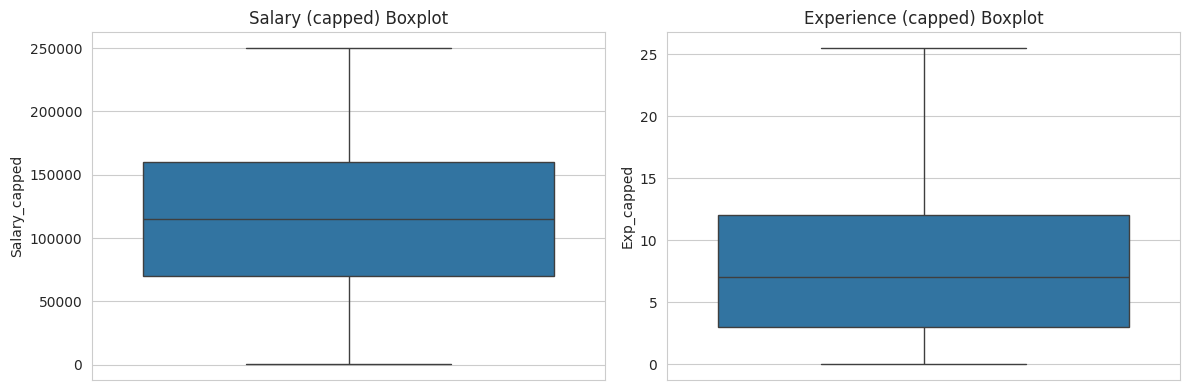

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_clean, y='Salary_capped', ax=axes[0])
axes[0].set_title('Salary (capped) Boxplot')
sns.boxplot(data=df_clean, y='Exp_capped', ax=axes[1])
axes[1].set_title('Experience (capped) Boxplot')
plt.tight_layout()
plt.show()

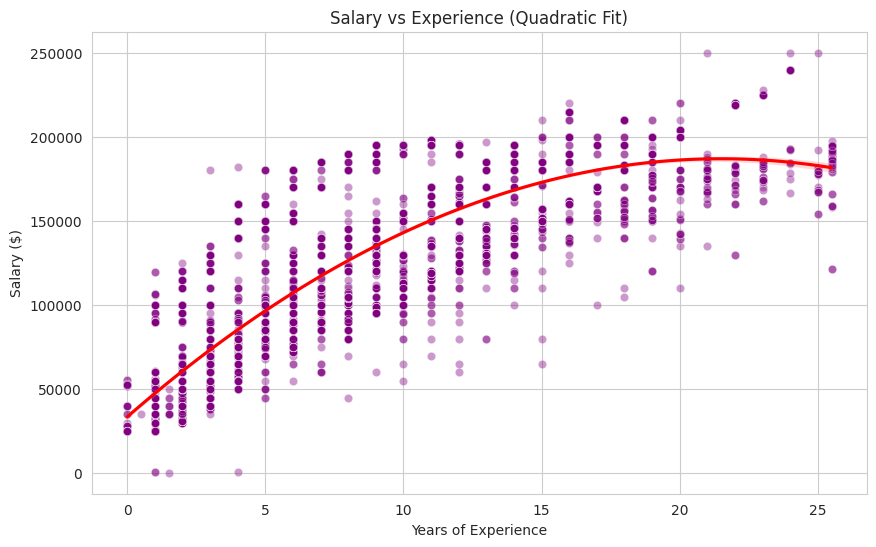

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Exp_capped', y='Salary_capped',
                alpha=0.4, color='purple')

sns.regplot(data=df_clean,
            x='Exp_capped',
            y='Salary_capped',
            scatter=False,
            order=2,   # quadratic
            color='red')

plt.title('Salary vs Experience (Quadratic Fit)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.show()

In [12]:

# Center Experience (reduces multicollinearity)
df_clean['Exp_centered'] = df_clean['Exp_capped'] - df_clean['Exp_capped'].mean()
df_clean['Exp_centered_sq'] = df_clean['Exp_centered'] ** 2

# Recreate interaction using centered experience
df_clean['Exp_x_Female'] = df_clean['Exp_centered'] * df_clean['IsFemale']

# Final modeling columns
final_columns = [
    'Exp_centered',
    'Exp_centered_sq',
    'EduOrdinal',
    'IsFemale',
    'Exp_x_Female',
    'Edu_x_Female',
    'Salary_capped'
]

df_model = df_clean[final_columns].copy().reset_index(drop=True)

print("Final modeling data shape:", df_model.shape)
print(df_model.head())

# Save cleaned dataset
df_model.to_csv('/content/cleaned_salary_data.csv', index=False)

Final modeling data shape: (6697, 7)
   Exp_centered  Exp_centered_sq  EduOrdinal  IsFemale  Exp_x_Female  \
0     -3.053009         9.320863         2.0         0     -0.000000   
1     -5.053009        25.532898         3.0         1     -5.053009   
2      6.946991        48.260687         4.0         0      0.000000   
3     -1.053009         1.108828         2.0         1     -1.053009   
4     11.946991       142.730598         3.0         0      0.000000   

   Edu_x_Female  Salary_capped  
0           0.0        90000.0  
1           3.0        65000.0  
2           0.0       150000.0  
3           2.0        60000.0  
4           0.0       200000.0  


In [13]:
# define Models
y = df_model['Salary_capped']

# Model 1: Base + Quadratic
X_base = df_model[['Exp_centered',
                   'Exp_centered_sq',
                   'EduOrdinal']]

# Model 2: + Gender
X_gender = df_model[['Exp_centered',
                     'Exp_centered_sq',
                     'EduOrdinal',
                     'IsFemale']]

# Model 3: + Interactions
X_interact = df_model[['Exp_centered',
                       'Exp_centered_sq',
                       'EduOrdinal',
                       'IsFemale',
                       'Exp_x_Female',
                       'Edu_x_Female']]
print("Model 1 features:", X_base.columns.tolist())
print("Model 2 features:", X_gender.columns.tolist())
print("Model 3 features:", X_interact.columns.tolist())

Model 1 features: ['Exp_centered', 'Exp_centered_sq', 'EduOrdinal']
Model 2 features: ['Exp_centered', 'Exp_centered_sq', 'EduOrdinal', 'IsFemale']
Model 3 features: ['Exp_centered', 'Exp_centered_sq', 'EduOrdinal', 'IsFemale', 'Exp_x_Female', 'Edu_x_Female']


In [14]:
# TRAIN-TEST SPLIT
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

X_train_gender, X_test_gender, _, _ = train_test_split(
    X_gender, y, test_size=0.2, random_state=42
)

X_train_interact, X_test_interact, _, _ = train_test_split(
    X_interact, y, test_size=0.2, random_state=42
)

# Add constant for statsmodels
X_train_base_sm = sm.add_constant(X_train_base)
X_test_base_sm = sm.add_constant(X_test_base)

X_train_gender_sm = sm.add_constant(X_train_gender)
X_test_gender_sm = sm.add_constant(X_test_gender)

X_train_interact_sm = sm.add_constant(X_train_interact)
X_test_interact_sm = sm.add_constant(X_test_interact)

print(f"Training set size: {len(y_train)}")
print(f"Test set size: {len(y_test)}")


Training set size: 5357
Test set size: 1340


In [15]:
# 8️ TRAIN MODEL (ROBUST SE)

model1 = sm.OLS(y_train, X_train_base_sm).fit(cov_type='HC3')
model2 = sm.OLS(y_train, X_train_gender_sm).fit(cov_type='HC3')
model3 = sm.OLS(y_train, X_train_interact_sm).fit(cov_type='HC3')

In [16]:
# model summaries
print("\n" + "="*70)
print("MODEL 1: Base + Quadratic (Robust SE - HC3)")
print("="*70)
print(model1.summary())

print("\n" + "="*70)
print("MODEL 2: + Gender (Robust SE - HC3)")
print("="*70)
print(model2.summary())

print("\n" + "="*70)
print("MODEL 3: + Interactions (Robust SE - HC3)")
print("="*70)
print(model3.summary())


MODEL 1: Base + Quadratic (Robust SE - HC3)
                            OLS Regression Results                            
Dep. Variable:          Salary_capped   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     8630.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:13:20   Log-Likelihood:                -62180.
No. Observations:                5357   AIC:                         1.244e+05
Df Residuals:                    5353   BIC:                         1.244e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [17]:
y_pred1 = model1.predict(X_test_base_sm)
y_pred2 = model2.predict(X_test_gender_sm)
y_pred3 = model3.predict(X_test_interact_sm)

In [18]:
# MODEL EVALUATION
def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{name} – Test Set Performance")
    print("-" * 50)
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : ${rmse:,.2f}")
    print(f"MAE  : ${mae:,.2f}")

    return {'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae}


res1 = evaluate(y_test, y_pred1, "Model 1 (Base)")
res2 = evaluate(y_test, y_pred2, "Model 2 (+ Gender)")
res3 = evaluate(y_test, y_pred3, "Model 3 (+ Interactions)")


# Create comparison table
results_df = pd.DataFrame([res1, res2, res3])
print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(results_df.sort_values(by="R2", ascending=False))


Model 1 (Base) – Test Set Performance
--------------------------------------------------
R²   : 0.7506
RMSE : $26,614.89
MAE  : $20,306.38

Model 2 (+ Gender) – Test Set Performance
--------------------------------------------------
R²   : 0.7534
RMSE : $26,466.47
MAE  : $20,039.88

Model 3 (+ Interactions) – Test Set Performance
--------------------------------------------------
R²   : 0.7536
RMSE : $26,453.14
MAE  : $20,036.91

MODEL COMPARISON TABLE
                      Model        R2          RMSE           MAE
2  Model 3 (+ Interactions)  0.753630  26453.136604  20036.906785
1        Model 2 (+ Gender)  0.753382  26466.473090  20039.884817
0            Model 1 (Base)  0.750608  26614.888490  20306.375955


In [19]:
# CROSS-VALIDATION
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

cv1 = cross_val_score(lr, X_base, y, cv=kf, scoring='r2')
cv2 = cross_val_score(lr, X_gender, y, cv=kf, scoring='r2')
cv3 = cross_val_score(lr, X_interact, y, cv=kf, scoring='r2')

print("\nCross-validation R² (mean ± std):")
print("-" * 50)
print(f"Model 1: {cv1.mean():.4f} ± {cv1.std():.4f}")
print(f"Model 2: {cv2.mean():.4f} ± {cv2.std():.4f}")
print(f"Model 3: {cv3.mean():.4f} ± {cv3.std():.4f}")


Cross-validation R² (mean ± std):
--------------------------------------------------
Model 1: 0.7454 ± 0.0134
Model 2: 0.7474 ± 0.0136
Model 3: 0.7477 ± 0.0138


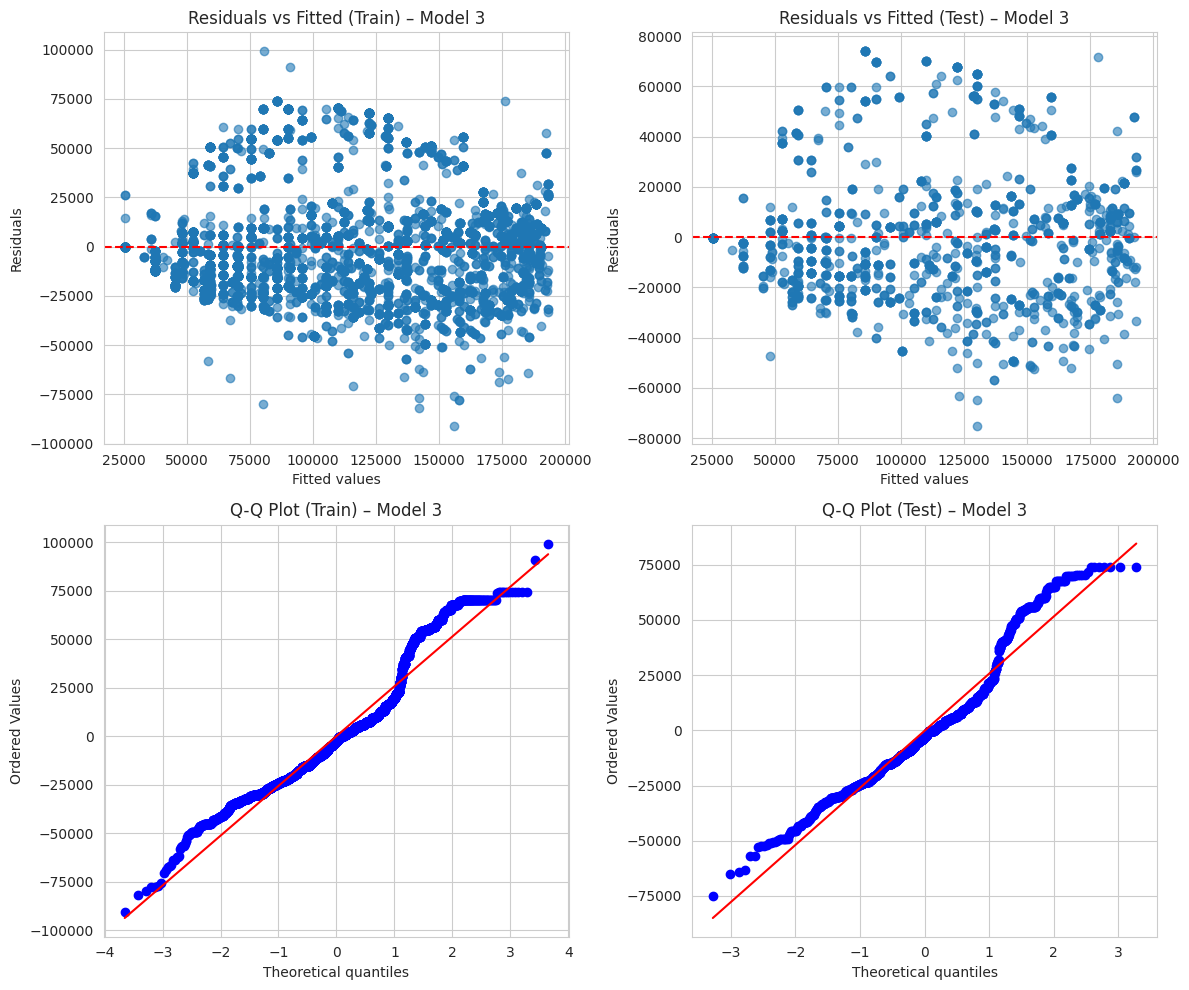

In [20]:
#  RESIDUAL DIAGNOSTICS
# Use final chosen model (Model 3)
train_pred = model3.predict(X_train_interact_sm)
test_pred = model3.predict(X_test_interact_sm)

train_resid = y_train - train_pred
test_resid = y_test - test_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted (Train)

axes[0,0].scatter(train_pred, train_resid, alpha=0.6)
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set_xlabel('Fitted values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted (Train) – Model 3')


# Residuals vs Fitted (Test)

axes[0,1].scatter(test_pred, test_resid, alpha=0.6)
axes[0,1].axhline(y=0, color='red', linestyle='--')
axes[0,1].set_xlabel('Fitted values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals vs Fitted (Test) – Model 3')


# Q-Q Plot (Train)

stats.probplot(train_resid, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Train) – Model 3')


# Q-Q Plot (Test)
stats.probplot(test_resid, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot (Test) – Model 3')

plt.tight_layout()
plt.show()

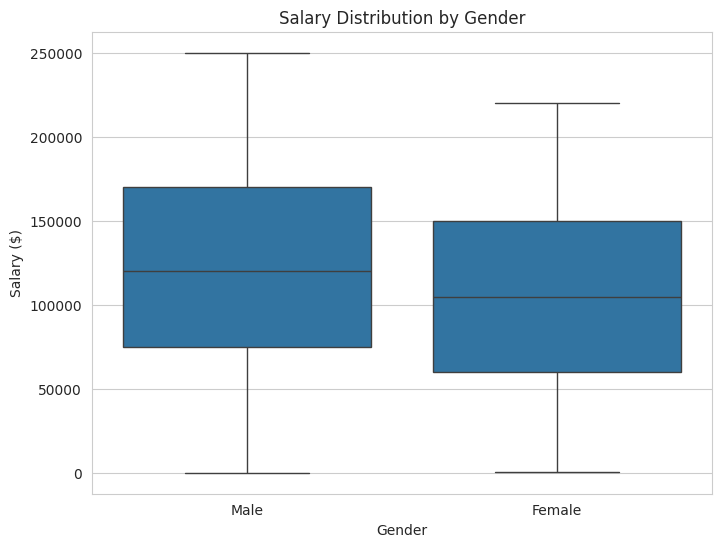

In [21]:
# Gender Salaray Distribution
df_model['GenderLabel'] = df_model['IsFemale'].map({0: 'Male', 1: 'Female'})

plt.figure(figsize=(8,6))
sns.boxplot(data=df_model, x='GenderLabel', y='Salary_capped')

plt.title('Salary Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Salary ($)')
plt.show()

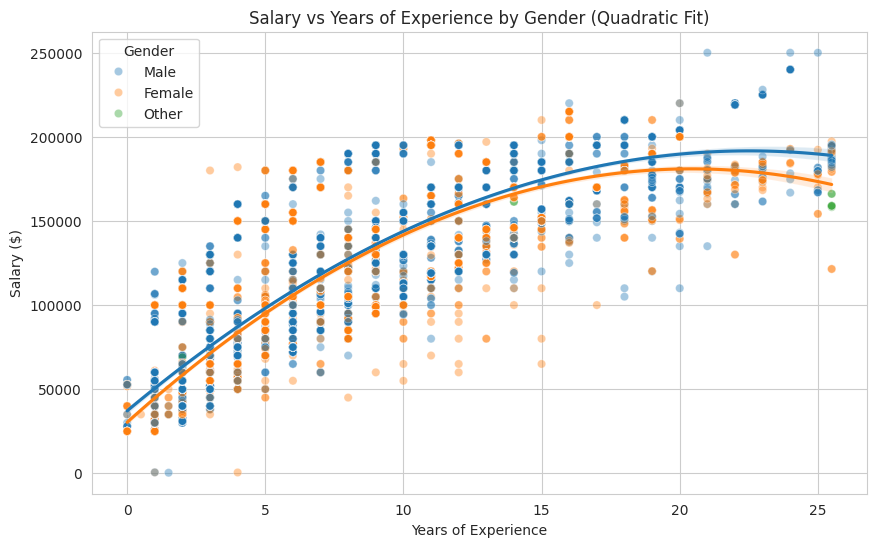

In [22]:
# Salary vs Experience by Gender
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='Exp_capped',
    y='Salary_capped',
    hue='Gender',
    alpha=0.4
)

sns.regplot(
    data=df_clean[df_clean['Gender'] == 'Male'],
    x='Exp_capped',
    y='Salary_capped',
    scatter=False,
    order=2
)

sns.regplot(
    data=df_clean[df_clean['Gender'] == 'Female'],
    x='Exp_capped',
    y='Salary_capped',
    scatter=False,
    order=2
)

plt.title('Salary vs Years of Experience by Gender (Quadratic Fit)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.show()

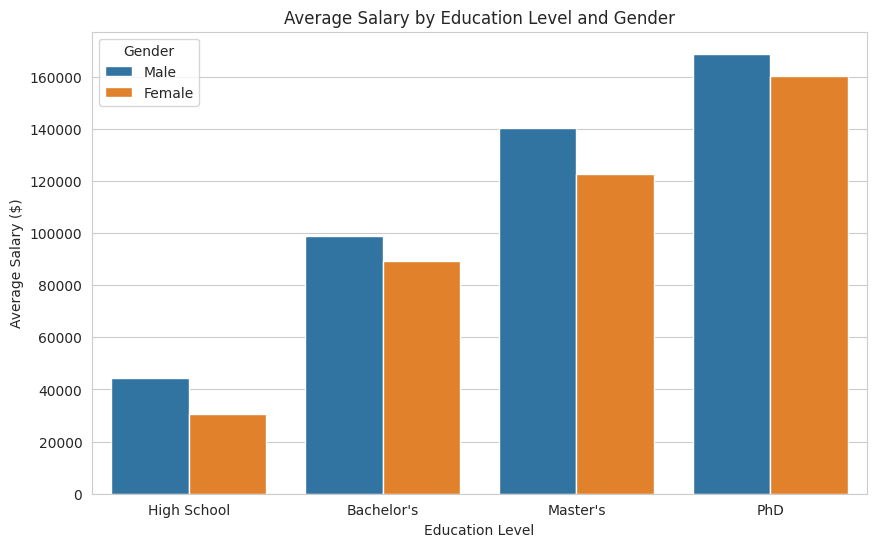

In [23]:
# Create readable labels
edu_labels = {1: 'High School', 2: "Bachelor's", 3: "Master's", 4: 'PhD'}
df_model['EduLabel'] = df_model['EduOrdinal'].map(edu_labels)

df_model['GenderLabel'] = df_model['IsFemale'].map({0: 'Male', 1: 'Female'})

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_model,
    x='EduLabel',
    y='Salary_capped',
    hue='GenderLabel',
    order=['High School', "Bachelor's", "Master's", 'PhD'],
    errorbar=None
)

plt.title('Average Salary by Education Level and Gender')
plt.xlabel('Education Level')
plt.ylabel('Average Salary ($)')
plt.legend(title='Gender')
plt.show()

In [24]:
#FINAL MODEL
best_features = [
    'Exp_centered',
    'Exp_centered_sq',
    'EduOrdinal',
    'IsFemale',
    'Exp_x_Female',
    'Edu_x_Female'
]

X_full = df_model[best_features]
X_full_sm = sm.add_constant(X_full)
y_full = df_model['Salary_capped']

# Use robust standard errors (recommended)
best_model = sm.OLS(y_full, X_full_sm).fit(cov_type='HC3')

print("\n" + "="*60)
print("FINAL MODEL SUMMARY (Full Data – Quadratic + Interactions)")
print("="*60)
print(best_model.summary())



FINAL MODEL SUMMARY (Full Data – Quadratic + Interactions)
                            OLS Regression Results                            
Dep. Variable:          Salary_capped   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     5648.
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:13:28   Log-Likelihood:                -77702.
No. Observations:                6697   AIC:                         1.554e+05
Df Residuals:                    6690   BIC:                         1.555e+05
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [25]:
#  SAVE FINAL MODEL
drive_path = '/content/drive/MyDrive/Gender_Pay_Equality_Project/'
os.makedirs(drive_path, exist_ok=True)

model_path = os.path.join(drive_path, 'Gender_Pay_Equality_model.pkl')
features_path = os.path.join(drive_path, 'Gender_Pay_Equality_features.pkl')

# Save model
joblib.dump(best_model, model_path)

# Save feature names (important for future predictions)
feature_names = list(X_full_sm.columns)
joblib.dump(feature_names, features_path)

if os.path.exists(model_path):
    print("Model successfully saved.")
else:
    print("Model saving failed.")

Model successfully saved.
